<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session25: DBSCAN</font></h3>
<h3 align="center">Zahra Amini</h3>

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

Text(0, 0.5, 'Y')

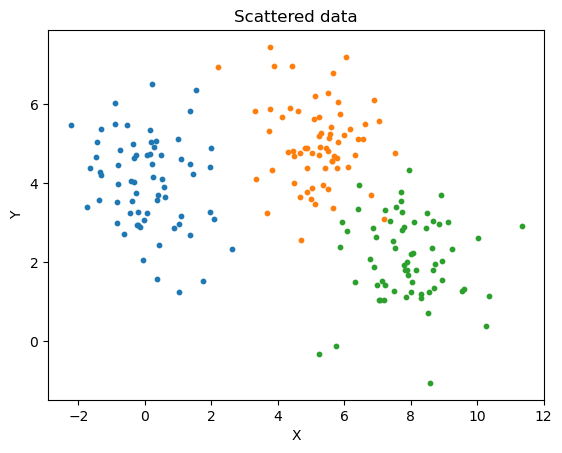

In [2]:
centers = [(0, 4), (5, 5) , (8,2)]
cluster_std = [1.2, 1, 1.1]

X, y= make_blobs(n_samples=200, cluster_std=cluster_std, centers=centers, n_features=2, random_state=1)

plt.scatter(X[y == 0, 0], X[y == 0, 1], s=10, label="Cluster1")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=10, label="Cluster2")
plt.scatter(X[y == 2, 0], X[y == 2, 1], s=10, label="Cluster3")
plt.title("Scattered data")
plt.xlabel('X')
plt.ylabel('Y')

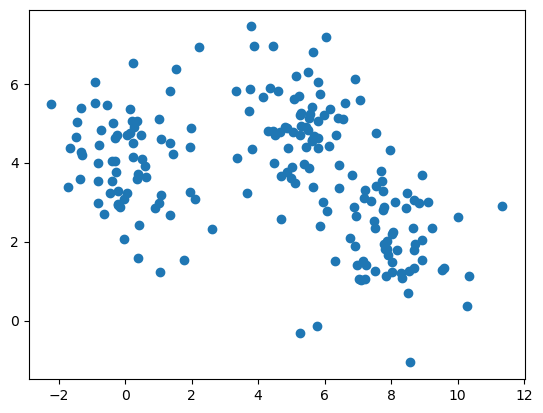

In [3]:
plt.scatter(X[:,0],X[:,1])

# DBSCAN

In [4]:
def check_point(eps, minpts, df, index):
    
    X, y = df.iloc[index]['X'], df.iloc[index]['Y']
    
    temp = df[((np.abs(X-df['X']) <= eps) & (np.abs(y- df['Y']) <= eps)) & (df.index != index)]
    
    if len(temp) >= minpts:
        # datafram, core, border, noise
        return(temp.index, True, False, False)
    
    elif(len(temp) < minpts) and len(temp) > 0:
        return(temp.index, False, True, False)
    
    elif len(temp) == 0:
        return(temp.index, False, False, True)

In [5]:
def DBSCAN(eps, minpts, df):
    C = 1
    unvisited=list(df.index)
    current_set = set()
    clusters = []
    
    while (len(unvisited)!= 0):
        
        first_point = True
        
        #random choose
        current_set.add(random.choice(unvisited))
        
        while len(current_set) != 0:
            
            current_idx = current_set.pop()
            
            neigh_idx, iscore, isborder, isnoise = check_point(eps, minpts, df, current_idx)
            
            
            if (isborder & first_point):
                
                clusters.append((current_idx, 0))
                clusters.extend(list(zip(neigh_idx, [0 for _ in range(len(neigh_idx))])))
                
                unvisited.remove(current_idx)
                
                unvisited = [p for p in unvisited if p not in neigh_idx]
                continue
            
            unvisited.remove(current_idx)
            
            neigh_idx = set(neigh_idx) & set(unvisited)
            
            if iscore:
                first_point = False
                
                clusters.append((current_idx, C))
                
                current_set.update(neigh_idx)
            
            elif isborder:
                clusters.append((current_idx, C))
                
                continue
                
            elif isnoise:
                clusters.append((current_idx, 0))
                
                continue
            
        if not first_point:
            C+=1
    return clusters

In [6]:
data = pd.DataFrame(X, columns=["X", "Y"])

In [7]:
eps = 0.6
minpts = 3

cluster_L = DBSCAN(eps, minpts, data)

In [8]:
# cluster_L

In [9]:
idx, cluster = list(zip(*cluster_L))

In [10]:
cluster_df = pd.DataFrame(cluster_L, columns=["idx", "cluster"])

Text(0, 0.5, 'Y')

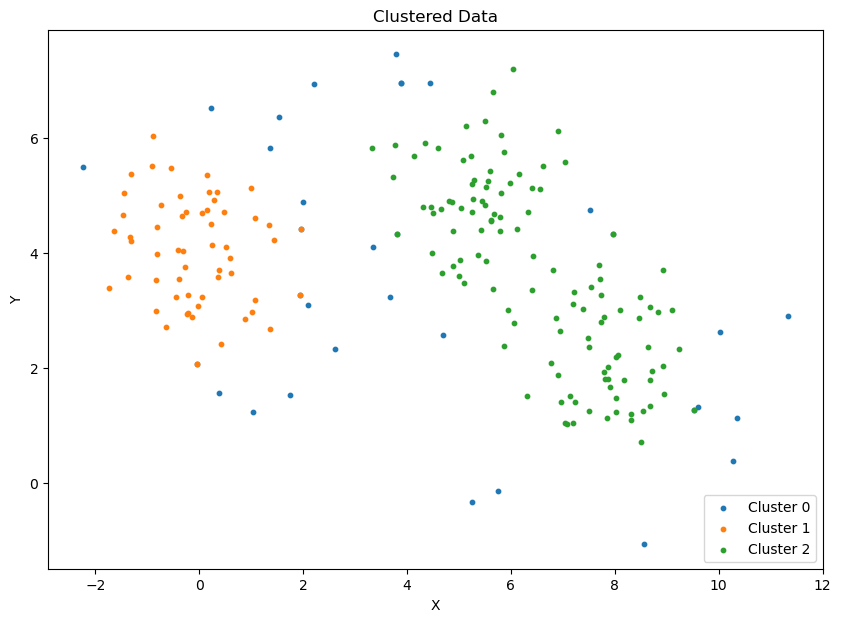

In [11]:
plt.figure(figsize=(10, 7))

for clt in np.unique(cluster):
    plt.scatter(X[cluster_df["idx"][cluster_df["cluster"] == clt].values, 0],
                X[cluster_df["idx"][cluster_df["cluster"] == clt].values, 1], 
                s=10, label=f"Cluster{clt}")

plt.legend([f"Cluster {clt}" for clt in np.unique(cluster)], loc ="lower right")
plt.title('Clustered Data')
plt.xlabel('X')
plt.ylabel('Y')

# DBSCAN ---> sklearn

In [12]:
from sklearn.cluster import DBSCAN

In [13]:
clustring = DBSCAN(eps=0.6, min_samples=3).fit(X)

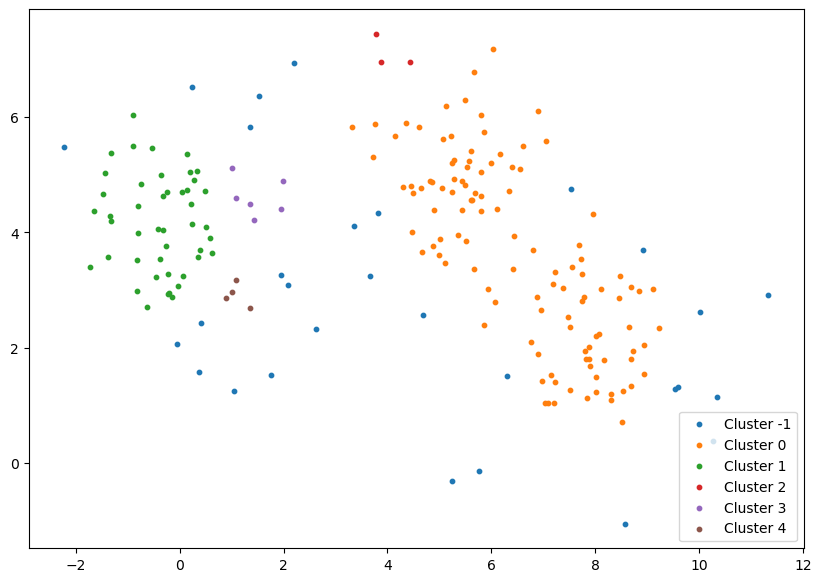

In [14]:
plt.figure(figsize=(10,7))
for clust in np.unique(clustring.labels_):
    plt.scatter(X[clustring.labels_ == clust, 0], X[clustring.labels_ == clust, 1], s=10, label=f"Cluster{clustring.labels_}")

plt.legend([f"Cluster {clust}" for clust in np.unique(clustring.labels_)], loc ="lower right")

# Finished!